# Model vs Field data comparison for PV RESOLVE project.
## Based on DOE data prize sites 9069 (Simon Solar) and 7334 (Shine On Solar)
## Load Field data, SAM and DAS result files and run cap test
## Use solardatatools environment, pvcaptest v 0.14.0
## following example https://pvcaptest.readthedocs.io/en/stable/examples/complete_capacity_test.html

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import pvlib
import numpy as np
import os
from pathlib import Path
from datetime import datetime

In [3]:
plt.rcParams.update({'font.size': 22})
plt.rcParams['figure.figsize'] = (12, 4)

In [4]:
# import captest as pvc
import captest as ct
print(f'PVCaptest version {ct.__version__}')
from captest import capdata as pvc
from bokeh.io import output_notebook, show

# uncomment below two lines to use cptest.scatter_hv in notebook
import holoviews as hv
from holoviews import opts
hv.extension('bokeh')

#if working offline with the CapData.plot() method may fail
#run 'export BOKEH_RESOURCES=inline' at the command line before
#running the jupyter notebook

output_notebook()

PVCaptest version 0.14.0


C:\Users\cdeline\Documents\Python Scripts\pvcaptest\src\captest\capdata.py:67: UserWarning: Specifying a column grouping in an excel file will not work without the openpyxl package.
  warnings.warn(


Loading BokehJS ...

In [5]:
# Simon Solar data - saved in Analysis_9069.py

# run PVCaptest

# instantiating a CapData object, which we will use to load and store the field data. das = string1. das2 = string2.
das = ct.load_data('./data/9069_subset.csv')



In [6]:
# immediately filter to a subset from 9/1/22 through 10/31/22.  Although agg_filters will reset this so we need to start w agg_filters
das.reset_filter()
das.agg_sensors(agg_map={'_inv_':'sum', 'irr_poa_':'median', 'temp_amb_':'median', 'wind__':'median'})


In [8]:

# acceptable times: 2/1/22 - 3/10/22
# meter_2_ac_power_kw has a dropoff starting 5/15/22.  
# poa_irradiance_02b has best availability
# wind_speed cuts out in March 11 2022

start_date = pd.to_datetime('2022-02-01 6:0:0-05:00')
end_date = pd.to_datetime('2022-03-10 20:0:0-05:00') 

#das.filter_time(start=start_date, end=end_date)
das.data = das.data[(das.data.index >= start_date) & (das.data.index <= end_date)]

In [9]:
print([k for k in das.column_groups])
print(das.column_groups._mtr_)
print(das.column_groups.irr_poa_)
print(das.column_groups.temp_amb_)
print(das.column_groups.wind__)
print([k for k in das.column_groups._inv_])

['irr_ghi_', 'irr_poa_ref_cell', 'pf_inv_', 'irr_poa_', '_mtr_', 'temp_amb_', 'temp_mod_', 'wind__', 'temp__', '_inv_', 'agg']
['meter_1_ac_power_kw', 'meter_2_ac_power_kw']
['poa_irradiance_02a', 'poa_irradiance_02b', 'poa_irradiance_08']
['ambient_temperature_median']
['wind_speed_ms']
['inverter_01_ac_power_(kw)', 'inverter_02_ac_power_(kw)', 'inverter_03_ac_power_(kw)', 'inverter_04_ac_power_(kw)', 'inverter_05_ac_power_(kw)', 'inverter_06_ac_power_(kw)', 'inverter_07_ac_power_(kw)', 'inverter_08_ac_power_(kw)', 'inverter_09_ac_power_(kw)', 'inverter_10_ac_power_(kw)', 'inverter_11_ac_power_(kw)', 'inverter_12_ac_power_(kw)', 'inverter_13_ac_power_(kw)', 'inverter_14_ac_power_(kw)', 'inverter_15_ac_power_(kw)', 'inverter_16_ac_power_(kw)', 'inverter_17_ac_power_(kw)', 'inverter_18_ac_power_(kw)', 'inverter_19_ac_power_(kw)', 'inverter_20_ac_power_(kw)', 'inverter_21_ac_power_(kw)', 'inverter_22_ac_power_(kw)', 'inverter_23_ac_power_(kw)', 'inverter_24_ac_power_(kw)', 'inverter_25_a

In [8]:
# browse the different data channels
#combine = {'inv_sum_mtr_pwr': ['mtr', 'inv.*agg'], 'irr_all':['irr_poa', 'irr_ghi'], 'temp_all':['temp_amb', 'temp_mod']}
combine = {'irr_all':['poa_irr', 'ghi_irr'], 'temp_all':['ambient_temp', 'module_temp']}
default_groups = ['inv_sum_mtr_pwr', 'irr_all', 'temp_all']
das.plot(combine=combine, default_groups=default_groups, width=900)


BokehModel(combine_events=True, render_bundle={'docs_json': {'581d5a08-b546-4e00-8b5c-648b47b2e584': {'version…

In [10]:
#das.regression_formula = 'power ~ poa + I(poa * poa) + I(poa * t_amb) + I(poa * w_vel) - 1'
das.regression_formula = 'power ~ poa + I(poa * poa) + I(poa * t_amb)  - 1'  # using Tmod instead of ambient temperature

In [11]:
# Set regression columns
#das.set_regression_cols(power='inverter_07_ac_power_(kw)', poa='poa_irradiance_02b', 
#                        t_amb='ambient_temperature_median', w_vel='wind_speed_ms')
das.reset_filter()

das.data_filtered = das.data_filtered[(das.data_filtered['_inv__sum_agg'].notna())&(das.data_filtered['poa_irradiance_02b'].notna())
                    &(das.data_filtered['module_temperature_median'].notna())&(das.data_filtered['wind_speed_ms'].notna())]

das.set_regression_cols(power='_inv__sum_agg', poa='poa_irradiance_02b', 
                        t_amb='module_temperature_median', w_vel='wind_speed_ms') #t_amb='ambient_temperature_median', w_vel='wind_speed_ms'


das.filter_irr(200, 2000)

#das.filter_sensors() # removes almost everything for some reason...
#das.filter_custom(pd.DataFrame.dropna) # removes all data for some reason...
das.filter_outliers() # 

das.fit_regression(filter=True, summary=False)




NOTE: Regression used to filter outlying points.




In [12]:
das.rep_cond()
print(das.rc)

Reporting conditions saved to rc attribute.
     poa      t_amb     w_vel
0  767.0  28.605977  1.794749
     poa      t_amb     w_vel
0  767.0  28.605977  1.794749


In [13]:
das.filter_irr(0.5, 1.5, ref_val=das.rc['poa'][0])

In [14]:
das.scatter_hv()

:Scatter   [poa]   (power,index)

In [15]:
das.fit_regression(summary=False)

In [16]:
print(das.regression_results.summary())

                                 OLS Regression Results                                
Dep. Variable:                  power   R-squared (uncentered):                   0.998
Model:                            OLS   Adj. R-squared (uncentered):              0.998
Method:                 Least Squares   F-statistic:                          3.283e+05
Date:                Tue, 28 Apr 2026   Prob (F-statistic):                        0.00
Time:                        13:43:16   Log-Likelihood:                         -13321.
No. Observations:                1614   AIC:                                  2.665e+04
Df Residuals:                    1611   BIC:                                  2.666e+04
Df Model:                           3                                                  
Covariance Type:            nonrobust                                                  
                     coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------

In [19]:
# regression formula: P = G*(a0)
a = list(das.regression_results.params)
r = [das.rc.poa.iloc[0], das.rc.t_amb.iloc[0], das.rc.w_vel.iloc[0]]
power_predict = r[0]*(a[0] + a[1]*r[0] + a[2]*r[1])
print(f'Predicted power: {power_predict:.1f} kW')

Predicted power: 25660.6 kW


In [22]:
#!pip install selenium
#!conda install -c conda-forge firefox geckodriver

In [20]:
## Now functionalize the above procedure and run on all inverter channels.

def process_inverter_channel(das, power_col, rc=None):
    das.reset_filter()
    das.data_filtered = das.data_filtered[(das.data_filtered[power_col].notna()) &
                                          (das.data_filtered['poa_irradiance_02b'].notna()) &
                                          (das.data_filtered['module_temperature_median'].notna()) &
                                          (das.data_filtered['wind_speed_ms'].notna())]
    das.set_regression_cols(power=power_col, poa='poa_irradiance_02b',
                            t_amb='module_temperature_median', w_vel='wind_speed_ms')
    das.filter_irr(200, 2000)
    das.filter_outliers()
    das.fit_regression(filter=True, summary=False)
    if rc is None:
        das.rep_cond()
        print(das.rc)
    else:
        das.rc = rc
    das.filter_irr(0.5, 1.5, ref_val=das.rc['poa'][0])
    das.filter_irr(200, 900) # some clipping happening at high irradiance at 33MWac.
    das.fit_regression(summary=False)
    return das

def regression_predict(das):
    # regression formula: P = G*(a0)
    a = list(das.regression_results.params)
    r = [das.rc.poa.iloc[0], das.rc.t_amb.iloc[0], das.rc.w_vel.iloc[0]]
    power_predict = r[0]*(a[0] + a[1]*r[0] + a[2]*r[1])
    print(f'Predicted power: {power_predict:.1f} kW')
    return power_predict

In [21]:
rc = pd.DataFrame({'poa':[800], 't_amb':[20], 'w_vel':[1]})
print(rc)



   poa  t_amb  w_vel
0  800     20      1


In [ ]:
# set up a dataframe to store power_predict results for each inverter channel
power_predict_df = pd.DataFrame(columns=das.column_groups._inv_ + ['_inv__sum_agg'], index=['power_predict'])


# loop through all inverter channels and _inv__sum_agg to get regression results and predictions
#for power_col in ([das.column_groups._inv_[30]] ):
for power_col in (das.column_groups._inv_):
    print(f'Processing {power_col}...')
    das = process_inverter_channel(das, power_col, rc=rc)
    power_predict_df[power_col] = regression_predict(das)
    das_scatter = das.scatter_filters()
    hv.save(das_scatter, f'.\plots\{power_col}.html')
    hv.save(das_scatter, f'.\plots\{power_col}.png')

Processing inverter_31_ac_power_(kw)...
NOTE: Regression used to filter outlying points.


Predicted power: 638.7 kW


In [22]:
das.scatter_hv()

:Scatter   [poa]   (power,index)

In [45]:
power_predict_df.to_csv(r'.\data\9069_Feb_March_2022_800poa20tmod.csv')

([<matplotlib.axis.XTick at 0x1bfc75bc7a0>],
 [Text(1, 0, 'Inverter channels 1-40')])

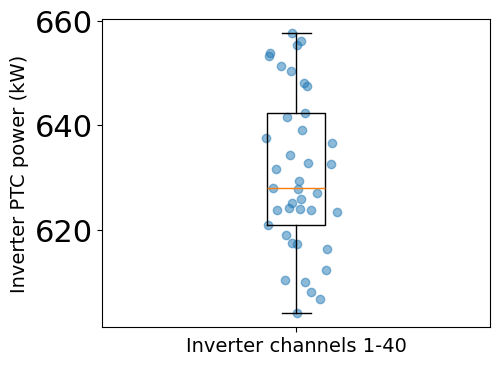

In [22]:
power_predict_df = pd.read_csv(r'.\data\9069_Feb_March_2022_800poa20tmod.csv', index_col=0)
labels =  [col.split('_')[1] for col in power_predict_df.columns[:-1]] + ['total']

# do a plot with a dithered scatterplot of the power_predict results
random = np.random.normal(1, 0.04, size=power_predict_df.T.shape) # add some random noise to the x values for better visualization
plt.figure(figsize=(5,4),)
plt.scatter(random[:-1], power_predict_df.T[:-1], alpha=0.5)
plt.boxplot(power_predict_df.T,  showfliers=False)
#plt.xticks(rotation=45)
plt.ylabel('Inverter PTC power (kW)', size=14)
# change the xtick labels to just be one tick with the label 'Inverter channel'
plt.xticks([1], ['Inverter channels 1-40'], size=14)


In [23]:
# Load SAM simulation results for 1 inverter
# initial try: 900kWdc, 700kWac, 1.286 DC/AC ratio
#df_temp = pd.read_csv('./data/9069_SAM_750AC_965DC.csv', index_col=0, parse_dates=True)
#df_temp.to_csv(r'.\data\9069_SAM_750AC_965DC_edited.csv')

sim = ct.load_data('./data/9069_SAM_825AC_965DC_edited.csv')

In [24]:
sim.column_groups

irr_ghi_:
    Weather file global horizontal irradiance | (W/m2)
irr_poa_:
    Plane of array irradiance | (W/m2)
temp_amb_:
    Weather file ambient temperature | (C)
temp_mod_:
    Module temperature | (C)
wind__:
    Weather file wind speed | (m/s)
_inv_:
    AC inverter power | (kW)

In [25]:
# Write over cptest.flt_sim dataframe with a copy of the original unfiltered dataframe
sim.reset_filter()
sim.set_regression_cols(power='_inv_', poa='irr_poa_', t_amb='temp_mod_', w_vel='wind__')
sim.regression_formula = 'power ~ poa + I(poa * poa) + I(poa * t_amb)  - 1'  # using Tmod instead of ambient temperature
sim.reset_filter()
sim.filter_time(test_date='2/11/2022', days=60)
sim.scatter_hv()

:Scatter   [poa]   (power,index)

In [26]:
sim.filter_irr(0.5, 1.5, ref_val=das.rc['poa'][0])
sim.fit_regression()

                                 OLS Regression Results                                
Dep. Variable:                  power   R-squared (uncentered):                   1.000
Model:                            OLS   Adj. R-squared (uncentered):              1.000
Method:                 Least Squares   F-statistic:                          1.216e+06
Date:                Tue, 28 Apr 2026   Prob (F-statistic):                        0.00
Time:                        13:44:12   Log-Likelihood:                         -726.28
No. Observations:                 242   AIC:                                      1459.
Df Residuals:                     239   BIC:                                      1469.
Df Model:                           3                                                  
Covariance Type:            nonrobust                                                  
                     coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------

In [29]:
das.rc = rc
sim.rc = rc

In [30]:
SAM_val = regression_predict(sim)

Predicted power: 688.1 kW


([<matplotlib.axis.XTick at 0x1bfc76bda00>],
 [Text(1, 0, 'Inverter channels 1-40')])

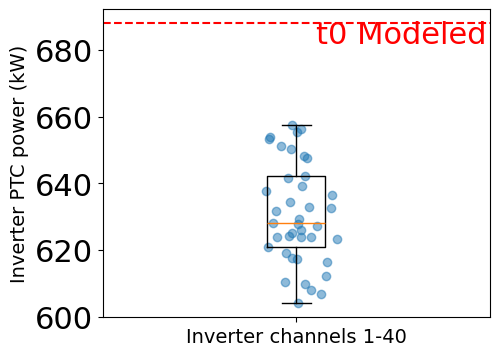

In [31]:
# repeat the above boxplot, include the SAM model value as a horizontal line with label
plt.figure(figsize=(5,4),)
plt.scatter(random[:-1], power_predict_df.T[:-1], alpha=0.5)
plt.boxplot(power_predict_df.T,  showfliers=False)
# add a horizontal line for the SAM prediction
plt.axhline(y=SAM_val, color='r', linestyle='--', label='SAM prediction')
# add annotation for the SAM line
plt.text(1.05, SAM_val-3.5, 't0 Modeled', color='r', va='center')
#plt.ylim(610, 700)
#plt.xticks(rotation=45)
plt.ylabel('Inverter PTC power (kW)', size=14)
# change the xtick labels to just be one tick with the label 'Inverter channel'
plt.xticks([1], ['Inverter channels 1-40'], size=14)

In [32]:
SAM_val

np.float64(688.0780023338843)

In [33]:
# apparent degradation rate. End - start is approx. 6 years (2022-2016)
p_mean = power_predict_df.T[:-1].mean()
print(f'Apparent degradation rate: -{(SAM_val - p_mean.iloc[0])/SAM_val/6*100:.2f}% per year median')
print(f'Apparent degradation: -{(SAM_val - p_mean.iloc[0])/SAM_val*100:.2f}% total')

Apparent degradation rate: -1.39% per year median
Apparent degradation: -8.34% total


Text(0.5, 1.0, 'POA vs RefCell, fit line y=1.0021x + 50.6')

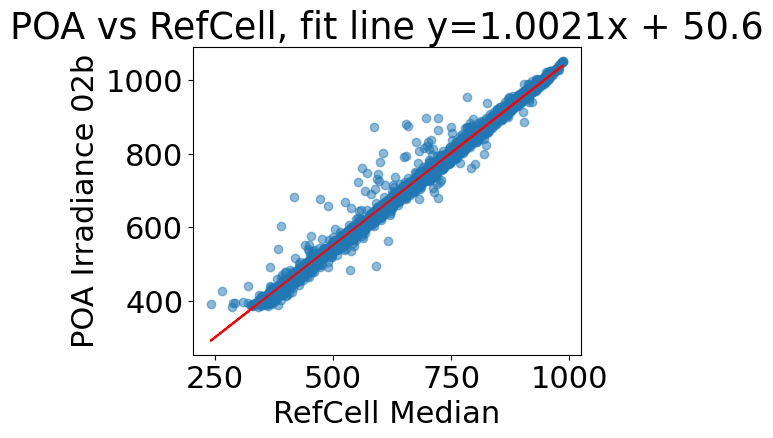

In [34]:

# issue: poa_irradiance_02b and refcell_median have a bias offset. 
fit = np.polyfit(das.data_filtered['reference_cell_poa_median'],das.data_filtered['poa_irradiance_02b'] , 1)
plt.figure(figsize=(5,4),)
plt.scatter(das.data_filtered['reference_cell_poa_median'], das.data_filtered['poa_irradiance_02b'], alpha=0.5)
plt.plot(das.data_filtered['reference_cell_poa_median'], fit[0]*das.data_filtered['reference_cell_poa_median'] + fit[1], color='r', label='Fit line')
plt.ylabel('POA Irradiance 02b')
plt.xlabel('RefCell Median')
plt.title(f'POA vs RefCell, fit line y={fit[0]:.4f}x + {fit[1]:.1f}')


In [35]:
# Run capacity test over time for combined inverter channel.
# start by re-loading all data, then just do time filter and regression fit for the combined inverter channel, then predict power at the reference conditions for each time period to see how it changes over time.
# startdate: 2016-02-17.   enddate: 2022-03-10 (data availability is limited after 3/10/22)
das_time = ct.load_data('./data/9069_subset.csv')

das_time.agg_sensors(agg_map={'_inv_':'sum', 'irr_poa_':'median', 'temp_amb_':'median', 'wind__':'median'})
#das_time.regression_formula = 'power ~ poa + I(poa * poa) + I(poa * t_amb) + I(poa * w_vel) - 1'
das_time.regression_formula = 'power ~ poa + I(poa * poa) + I(poa * t_amb)  - 1'  # using Tmod instead of ambient temperature
das_time.data['refcell_adj'] = das_time.data['reference_cell_poa_median']*fit[0] + fit[1]  # apply above adjustment y = 0.9997x+49.8 to match refcell to POA



In [69]:
das_time.plot()

BokehModel(combine_events=True, render_bundle={'docs_json': {'528e97b5-5c4a-41f9-8c28-c9d0954c7e11': {'version…

In [36]:
# Working datetimes: 2/2016, 1/2017, 1/2018, 1/2021, 1/2022, 1/2023

start_dates = pd.to_datetime(['2016-02-17 6:0:0-05:00', '2017-01-01 6:0:0-05:00', '2018-01-15 6:0:0-05:00',
               '2021-01-10 6:0:0-05:00', '2022-02-01 6:0:0-05:00'])
end_dates = pd.to_datetime(['2016-02-28 20:0:0-05:00', '2017-02-28 20:0:0-05:00', '2018-01-28 20:0:0-05:00',
             '2021-02-28 20:0:0-05:00', '2022-03-10 20:0:0-05:00'])

In [37]:
def process_inverter_channel_time(das_time, power_col, start, end):
    das_time.reset_filter()
    das_time.filter_time(start=start, end=end)
    das_time.set_regression_cols(power=power_col, poa='refcell_adj', 
                            t_amb='module_temperature_median', w_vel='wind_speed_ms')
    das_time.filter_irr(200, 2000)
    das_time.filter_outliers()
    das_time.fit_regression(filter=True, summary=False)
    das_time.rc = rc
    das_time.filter_irr(0.5, 1.5, ref_val=rc['poa'][0])
    das_time.filter_irr(200, 950) # some clipping happening at high irradiance at 33MWac.
    das_time.fit_regression(summary=False)
    if power_col == '_inv__sum_agg':
        return regression_predict(das_time) / 40
    else:
        return regression_predict(das_time)

In [38]:
power_predict_time = pd.DataFrame(columns=['power_predict'], index=start_dates.date)
for i in range(len(start_dates)):
    power_predict_time.iloc[i] = process_inverter_channel_time(das_time, '_inv__sum_agg', 
                                                         start_dates[i], end_dates[i]) 

NOTE: Regression used to filter outlying points.


Predicted power: 27415.6 kW
NOTE: Regression used to filter outlying points.


Predicted power: 27300.1 kW
NOTE: Regression used to filter outlying points.


Predicted power: 26857.6 kW
NOTE: Regression used to filter outlying points.


Predicted power: 25785.0 kW
NOTE: Regression used to filter outlying points.


Predicted power: 25256.4 kW


In [ ]:
# This takes a long time to run - reload the data below.
#for i in [0]:
for i in range(len(start_dates)):
    
    power_predict_time_df = pd.DataFrame(columns=das_time.column_groups._inv_ + ['_inv__sum_agg'], index=['power_predict'])

    # loop through all inverter channels and _inv__sum_agg to get regression results and predictions
    #for power_col in ([das.column_groups._inv_[30]] ):
    for power_col in (das_time.column_groups._inv_):
        print(f'Processing {start_dates[i].date().strftime("%Y-%m-%d")}_{power_col}...')
        power_predict_time_df[power_col] = process_inverter_channel_time(das_time, power_col, start_dates[i], end_dates[i])
        das_scatter = das_time.scatter_filters()
        #hv.save(das_scatter, f'.\plots\{power_col}.html')
        hv.save(das_scatter, f'.\plots\{start_dates[i].date().strftime("%Y-%m-%d")}_{power_col}.png')
    
    power_predict_time_df.to_csv(f'.\data\{start_dates[i].date().strftime("%Y-%m-%d")}_800poa20tmod.csv')



NOTE: Regression used to filter outlying points.


Predicted power: 27415.6 kW
Processing inverter_01_ac_power_(kw)...


C:\Users\cdeline\Documents\Python Scripts\pvcaptest\src\captest\capdata.py:2730: UserWarning: Poa and/or power columns contain missing values. Calling filter_missing on poa and power columns before continuing with filter_outliers.
  warnings.warn(


NOTE: Regression used to filter outlying points.


Predicted power: 687.7 kW
Processing inverter_02_ac_power_(kw)...


C:\Users\cdeline\Documents\Python Scripts\pvcaptest\src\captest\capdata.py:2730: UserWarning: Poa and/or power columns contain missing values. Calling filter_missing on poa and power columns before continuing with filter_outliers.
  warnings.warn(


NOTE: Regression used to filter outlying points.


Predicted power: 674.4 kW
Processing inverter_03_ac_power_(kw)...


C:\Users\cdeline\Documents\Python Scripts\pvcaptest\src\captest\capdata.py:2730: UserWarning: Poa and/or power columns contain missing values. Calling filter_missing on poa and power columns before continuing with filter_outliers.
  warnings.warn(


NOTE: Regression used to filter outlying points.


Predicted power: 693.4 kW
Processing inverter_04_ac_power_(kw)...


C:\Users\cdeline\Documents\Python Scripts\pvcaptest\src\captest\capdata.py:2730: UserWarning: Poa and/or power columns contain missing values. Calling filter_missing on poa and power columns before continuing with filter_outliers.
  warnings.warn(


NOTE: Regression used to filter outlying points.


Predicted power: 694.3 kW
Processing inverter_05_ac_power_(kw)...


C:\Users\cdeline\Documents\Python Scripts\pvcaptest\src\captest\capdata.py:2730: UserWarning: Poa and/or power columns contain missing values. Calling filter_missing on poa and power columns before continuing with filter_outliers.
  warnings.warn(


NOTE: Regression used to filter outlying points.


Predicted power: 694.7 kW
Processing inverter_06_ac_power_(kw)...


C:\Users\cdeline\Documents\Python Scripts\pvcaptest\src\captest\capdata.py:2730: UserWarning: Poa and/or power columns contain missing values. Calling filter_missing on poa and power columns before continuing with filter_outliers.
  warnings.warn(


NOTE: Regression used to filter outlying points.


Predicted power: 710.3 kW
Processing inverter_07_ac_power_(kw)...


C:\Users\cdeline\Documents\Python Scripts\pvcaptest\src\captest\capdata.py:2730: UserWarning: Poa and/or power columns contain missing values. Calling filter_missing on poa and power columns before continuing with filter_outliers.
  warnings.warn(


NOTE: Regression used to filter outlying points.


Predicted power: 704.4 kW
Processing inverter_08_ac_power_(kw)...


C:\Users\cdeline\Documents\Python Scripts\pvcaptest\src\captest\capdata.py:2730: UserWarning: Poa and/or power columns contain missing values. Calling filter_missing on poa and power columns before continuing with filter_outliers.
  warnings.warn(


NOTE: Regression used to filter outlying points.


Predicted power: 681.1 kW
Processing inverter_09_ac_power_(kw)...


C:\Users\cdeline\Documents\Python Scripts\pvcaptest\src\captest\capdata.py:2730: UserWarning: Poa and/or power columns contain missing values. Calling filter_missing on poa and power columns before continuing with filter_outliers.
  warnings.warn(


NOTE: Regression used to filter outlying points.


Predicted power: 697.8 kW
Processing inverter_10_ac_power_(kw)...


C:\Users\cdeline\Documents\Python Scripts\pvcaptest\src\captest\capdata.py:2730: UserWarning: Poa and/or power columns contain missing values. Calling filter_missing on poa and power columns before continuing with filter_outliers.
  warnings.warn(


NOTE: Regression used to filter outlying points.


Predicted power: 692.7 kW
Processing inverter_11_ac_power_(kw)...


C:\Users\cdeline\Documents\Python Scripts\pvcaptest\src\captest\capdata.py:2730: UserWarning: Poa and/or power columns contain missing values. Calling filter_missing on poa and power columns before continuing with filter_outliers.
  warnings.warn(


NOTE: Regression used to filter outlying points.


Predicted power: 706.2 kW
Processing inverter_12_ac_power_(kw)...


C:\Users\cdeline\Documents\Python Scripts\pvcaptest\src\captest\capdata.py:2730: UserWarning: Poa and/or power columns contain missing values. Calling filter_missing on poa and power columns before continuing with filter_outliers.
  warnings.warn(


NOTE: Regression used to filter outlying points.


Predicted power: 685.0 kW
Processing inverter_13_ac_power_(kw)...


C:\Users\cdeline\Documents\Python Scripts\pvcaptest\src\captest\capdata.py:2730: UserWarning: Poa and/or power columns contain missing values. Calling filter_missing on poa and power columns before continuing with filter_outliers.
  warnings.warn(


NOTE: Regression used to filter outlying points.


Predicted power: 694.9 kW
Processing inverter_14_ac_power_(kw)...


C:\Users\cdeline\Documents\Python Scripts\pvcaptest\src\captest\capdata.py:2730: UserWarning: Poa and/or power columns contain missing values. Calling filter_missing on poa and power columns before continuing with filter_outliers.
  warnings.warn(


NOTE: Regression used to filter outlying points.


Predicted power: 714.8 kW
Processing inverter_15_ac_power_(kw)...


C:\Users\cdeline\Documents\Python Scripts\pvcaptest\src\captest\capdata.py:2730: UserWarning: Poa and/or power columns contain missing values. Calling filter_missing on poa and power columns before continuing with filter_outliers.
  warnings.warn(


NOTE: Regression used to filter outlying points.


Predicted power: 703.0 kW
Processing inverter_16_ac_power_(kw)...


C:\Users\cdeline\Documents\Python Scripts\pvcaptest\src\captest\capdata.py:2730: UserWarning: Poa and/or power columns contain missing values. Calling filter_missing on poa and power columns before continuing with filter_outliers.
  warnings.warn(


NOTE: Regression used to filter outlying points.


Predicted power: 668.4 kW
Processing inverter_17_ac_power_(kw)...


C:\Users\cdeline\Documents\Python Scripts\pvcaptest\src\captest\capdata.py:2730: UserWarning: Poa and/or power columns contain missing values. Calling filter_missing on poa and power columns before continuing with filter_outliers.
  warnings.warn(


NOTE: Regression used to filter outlying points.


Predicted power: 710.0 kW
Processing inverter_18_ac_power_(kw)...


C:\Users\cdeline\Documents\Python Scripts\pvcaptest\src\captest\capdata.py:2730: UserWarning: Poa and/or power columns contain missing values. Calling filter_missing on poa and power columns before continuing with filter_outliers.
  warnings.warn(


NOTE: Regression used to filter outlying points.


Predicted power: 703.5 kW
Processing inverter_19_ac_power_(kw)...


C:\Users\cdeline\Documents\Python Scripts\pvcaptest\src\captest\capdata.py:2730: UserWarning: Poa and/or power columns contain missing values. Calling filter_missing on poa and power columns before continuing with filter_outliers.
  warnings.warn(


NOTE: Regression used to filter outlying points.


Predicted power: 683.5 kW
Processing inverter_20_ac_power_(kw)...


C:\Users\cdeline\Documents\Python Scripts\pvcaptest\src\captest\capdata.py:2730: UserWarning: Poa and/or power columns contain missing values. Calling filter_missing on poa and power columns before continuing with filter_outliers.
  warnings.warn(


NOTE: Regression used to filter outlying points.


Predicted power: 695.6 kW
Processing inverter_21_ac_power_(kw)...


C:\Users\cdeline\Documents\Python Scripts\pvcaptest\src\captest\capdata.py:2730: UserWarning: Poa and/or power columns contain missing values. Calling filter_missing on poa and power columns before continuing with filter_outliers.
  warnings.warn(


NOTE: Regression used to filter outlying points.


Predicted power: 699.7 kW
Processing inverter_22_ac_power_(kw)...


C:\Users\cdeline\Documents\Python Scripts\pvcaptest\src\captest\capdata.py:2730: UserWarning: Poa and/or power columns contain missing values. Calling filter_missing on poa and power columns before continuing with filter_outliers.
  warnings.warn(


NOTE: Regression used to filter outlying points.


Predicted power: 710.9 kW
Processing inverter_23_ac_power_(kw)...


C:\Users\cdeline\Documents\Python Scripts\pvcaptest\src\captest\capdata.py:2730: UserWarning: Poa and/or power columns contain missing values. Calling filter_missing on poa and power columns before continuing with filter_outliers.
  warnings.warn(


NOTE: Regression used to filter outlying points.


Predicted power: 699.6 kW
Processing inverter_24_ac_power_(kw)...


C:\Users\cdeline\Documents\Python Scripts\pvcaptest\src\captest\capdata.py:2730: UserWarning: Poa and/or power columns contain missing values. Calling filter_missing on poa and power columns before continuing with filter_outliers.
  warnings.warn(


NOTE: Regression used to filter outlying points.


Predicted power: 714.7 kW
Processing inverter_25_ac_power_(kw)...


C:\Users\cdeline\Documents\Python Scripts\pvcaptest\src\captest\capdata.py:2730: UserWarning: Poa and/or power columns contain missing values. Calling filter_missing on poa and power columns before continuing with filter_outliers.
  warnings.warn(


NOTE: Regression used to filter outlying points.


Predicted power: 697.6 kW
Processing inverter_26_ac_power_(kw)...


C:\Users\cdeline\Documents\Python Scripts\pvcaptest\src\captest\capdata.py:2730: UserWarning: Poa and/or power columns contain missing values. Calling filter_missing on poa and power columns before continuing with filter_outliers.
  warnings.warn(


NOTE: Regression used to filter outlying points.


Predicted power: 707.9 kW
Processing inverter_27_ac_power_(kw)...


C:\Users\cdeline\Documents\Python Scripts\pvcaptest\src\captest\capdata.py:2730: UserWarning: Poa and/or power columns contain missing values. Calling filter_missing on poa and power columns before continuing with filter_outliers.
  warnings.warn(


NOTE: Regression used to filter outlying points.


Predicted power: 694.6 kW
Processing inverter_28_ac_power_(kw)...


C:\Users\cdeline\Documents\Python Scripts\pvcaptest\src\captest\capdata.py:2730: UserWarning: Poa and/or power columns contain missing values. Calling filter_missing on poa and power columns before continuing with filter_outliers.
  warnings.warn(


NOTE: Regression used to filter outlying points.


Predicted power: 689.3 kW
Processing inverter_29_ac_power_(kw)...


C:\Users\cdeline\Documents\Python Scripts\pvcaptest\src\captest\capdata.py:2730: UserWarning: Poa and/or power columns contain missing values. Calling filter_missing on poa and power columns before continuing with filter_outliers.
  warnings.warn(


NOTE: Regression used to filter outlying points.


Predicted power: 666.4 kW
Processing inverter_30_ac_power_(kw)...


C:\Users\cdeline\Documents\Python Scripts\pvcaptest\src\captest\capdata.py:2730: UserWarning: Poa and/or power columns contain missing values. Calling filter_missing on poa and power columns before continuing with filter_outliers.
  warnings.warn(


NOTE: Regression used to filter outlying points.


Predicted power: 657.3 kW
Processing inverter_31_ac_power_(kw)...


C:\Users\cdeline\Documents\Python Scripts\pvcaptest\src\captest\capdata.py:2730: UserWarning: Poa and/or power columns contain missing values. Calling filter_missing on poa and power columns before continuing with filter_outliers.
  warnings.warn(


NOTE: Regression used to filter outlying points.


Predicted power: 686.5 kW
Processing inverter_32_ac_power_(kw)...


C:\Users\cdeline\Documents\Python Scripts\pvcaptest\src\captest\capdata.py:2730: UserWarning: Poa and/or power columns contain missing values. Calling filter_missing on poa and power columns before continuing with filter_outliers.
  warnings.warn(


NOTE: Regression used to filter outlying points.


Predicted power: 690.8 kW
Processing inverter_33_ac_power_(kw)...


C:\Users\cdeline\Documents\Python Scripts\pvcaptest\src\captest\capdata.py:2730: UserWarning: Poa and/or power columns contain missing values. Calling filter_missing on poa and power columns before continuing with filter_outliers.
  warnings.warn(


NOTE: Regression used to filter outlying points.


Predicted power: 689.3 kW
Processing inverter_34_ac_power_(kw)...


C:\Users\cdeline\Documents\Python Scripts\pvcaptest\src\captest\capdata.py:2730: UserWarning: Poa and/or power columns contain missing values. Calling filter_missing on poa and power columns before continuing with filter_outliers.
  warnings.warn(


NOTE: Regression used to filter outlying points.


Predicted power: 688.9 kW
Processing inverter_35_ac_power_(kw)...


C:\Users\cdeline\Documents\Python Scripts\pvcaptest\src\captest\capdata.py:2730: UserWarning: Poa and/or power columns contain missing values. Calling filter_missing on poa and power columns before continuing with filter_outliers.
  warnings.warn(


NOTE: Regression used to filter outlying points.


Predicted power: 695.0 kW
Processing inverter_36_ac_power_(kw)...


C:\Users\cdeline\Documents\Python Scripts\pvcaptest\src\captest\capdata.py:2730: UserWarning: Poa and/or power columns contain missing values. Calling filter_missing on poa and power columns before continuing with filter_outliers.
  warnings.warn(


NOTE: Regression used to filter outlying points.


Predicted power: 700.1 kW
Processing inverter_37_ac_power_(kw)...


C:\Users\cdeline\Documents\Python Scripts\pvcaptest\src\captest\capdata.py:2730: UserWarning: Poa and/or power columns contain missing values. Calling filter_missing on poa and power columns before continuing with filter_outliers.
  warnings.warn(


NOTE: Regression used to filter outlying points.


Predicted power: 671.7 kW
Processing inverter_38_ac_power_(kw)...


C:\Users\cdeline\Documents\Python Scripts\pvcaptest\src\captest\capdata.py:2730: UserWarning: Poa and/or power columns contain missing values. Calling filter_missing on poa and power columns before continuing with filter_outliers.
  warnings.warn(


NOTE: Regression used to filter outlying points.


Predicted power: 688.3 kW
Processing inverter_39_ac_power_(kw)...


C:\Users\cdeline\Documents\Python Scripts\pvcaptest\src\captest\capdata.py:2730: UserWarning: Poa and/or power columns contain missing values. Calling filter_missing on poa and power columns before continuing with filter_outliers.
  warnings.warn(


NOTE: Regression used to filter outlying points.


Predicted power: 688.4 kW
Processing inverter_40_ac_power_(kw)...


C:\Users\cdeline\Documents\Python Scripts\pvcaptest\src\captest\capdata.py:2730: UserWarning: Poa and/or power columns contain missing values. Calling filter_missing on poa and power columns before continuing with filter_outliers.
  warnings.warn(


NOTE: Regression used to filter outlying points.


Predicted power: 671.2 kW
NOTE: Regression used to filter outlying points.


Predicted power: 27300.1 kW
Processing inverter_01_ac_power_(kw)...


C:\Users\cdeline\Documents\Python Scripts\pvcaptest\src\captest\capdata.py:2730: UserWarning: Poa and/or power columns contain missing values. Calling filter_missing on poa and power columns before continuing with filter_outliers.
  warnings.warn(


NOTE: Regression used to filter outlying points.


Predicted power: 682.4 kW
Processing inverter_02_ac_power_(kw)...


C:\Users\cdeline\Documents\Python Scripts\pvcaptest\src\captest\capdata.py:2730: UserWarning: Poa and/or power columns contain missing values. Calling filter_missing on poa and power columns before continuing with filter_outliers.
  warnings.warn(


NOTE: Regression used to filter outlying points.


Predicted power: 670.6 kW
Processing inverter_03_ac_power_(kw)...


C:\Users\cdeline\Documents\Python Scripts\pvcaptest\src\captest\capdata.py:2730: UserWarning: Poa and/or power columns contain missing values. Calling filter_missing on poa and power columns before continuing with filter_outliers.
  warnings.warn(


NOTE: Regression used to filter outlying points.


Predicted power: 684.0 kW
Processing inverter_04_ac_power_(kw)...


C:\Users\cdeline\Documents\Python Scripts\pvcaptest\src\captest\capdata.py:2730: UserWarning: Poa and/or power columns contain missing values. Calling filter_missing on poa and power columns before continuing with filter_outliers.
  warnings.warn(


NOTE: Regression used to filter outlying points.


Predicted power: 687.0 kW
Processing inverter_05_ac_power_(kw)...


C:\Users\cdeline\Documents\Python Scripts\pvcaptest\src\captest\capdata.py:2730: UserWarning: Poa and/or power columns contain missing values. Calling filter_missing on poa and power columns before continuing with filter_outliers.
  warnings.warn(


NOTE: Regression used to filter outlying points.


Predicted power: 689.8 kW
Processing inverter_06_ac_power_(kw)...


C:\Users\cdeline\Documents\Python Scripts\pvcaptest\src\captest\capdata.py:2730: UserWarning: Poa and/or power columns contain missing values. Calling filter_missing on poa and power columns before continuing with filter_outliers.
  warnings.warn(


NOTE: Regression used to filter outlying points.


Predicted power: 698.6 kW
Processing inverter_07_ac_power_(kw)...


C:\Users\cdeline\Documents\Python Scripts\pvcaptest\src\captest\capdata.py:2730: UserWarning: Poa and/or power columns contain missing values. Calling filter_missing on poa and power columns before continuing with filter_outliers.
  warnings.warn(


NOTE: Regression used to filter outlying points.


Predicted power: 708.6 kW
Processing inverter_08_ac_power_(kw)...


C:\Users\cdeline\Documents\Python Scripts\pvcaptest\src\captest\capdata.py:2730: UserWarning: Poa and/or power columns contain missing values. Calling filter_missing on poa and power columns before continuing with filter_outliers.
  warnings.warn(


NOTE: Regression used to filter outlying points.


Predicted power: 690.2 kW
Processing inverter_09_ac_power_(kw)...


C:\Users\cdeline\Documents\Python Scripts\pvcaptest\src\captest\capdata.py:2730: UserWarning: Poa and/or power columns contain missing values. Calling filter_missing on poa and power columns before continuing with filter_outliers.
  warnings.warn(


NOTE: Regression used to filter outlying points.


Predicted power: 693.8 kW
Processing inverter_10_ac_power_(kw)...


C:\Users\cdeline\Documents\Python Scripts\pvcaptest\src\captest\capdata.py:2730: UserWarning: Poa and/or power columns contain missing values. Calling filter_missing on poa and power columns before continuing with filter_outliers.
  warnings.warn(


NOTE: Regression used to filter outlying points.


Predicted power: 698.6 kW
Processing inverter_11_ac_power_(kw)...


C:\Users\cdeline\Documents\Python Scripts\pvcaptest\src\captest\capdata.py:2730: UserWarning: Poa and/or power columns contain missing values. Calling filter_missing on poa and power columns before continuing with filter_outliers.
  warnings.warn(


NOTE: Regression used to filter outlying points.


Predicted power: 696.4 kW
Processing inverter_12_ac_power_(kw)...


C:\Users\cdeline\Documents\Python Scripts\pvcaptest\src\captest\capdata.py:2730: UserWarning: Poa and/or power columns contain missing values. Calling filter_missing on poa and power columns before continuing with filter_outliers.
  warnings.warn(


NOTE: Regression used to filter outlying points.


Predicted power: 693.7 kW
Processing inverter_13_ac_power_(kw)...


C:\Users\cdeline\Documents\Python Scripts\pvcaptest\src\captest\capdata.py:2730: UserWarning: Poa and/or power columns contain missing values. Calling filter_missing on poa and power columns before continuing with filter_outliers.
  warnings.warn(


NOTE: Regression used to filter outlying points.


Predicted power: 687.8 kW
Processing inverter_14_ac_power_(kw)...


C:\Users\cdeline\Documents\Python Scripts\pvcaptest\src\captest\capdata.py:2730: UserWarning: Poa and/or power columns contain missing values. Calling filter_missing on poa and power columns before continuing with filter_outliers.
  warnings.warn(


NOTE: Regression used to filter outlying points.


Predicted power: 704.0 kW
Processing inverter_15_ac_power_(kw)...


C:\Users\cdeline\Documents\Python Scripts\pvcaptest\src\captest\capdata.py:2730: UserWarning: Poa and/or power columns contain missing values. Calling filter_missing on poa and power columns before continuing with filter_outliers.
  warnings.warn(


NOTE: Regression used to filter outlying points.


Predicted power: 704.1 kW
Processing inverter_16_ac_power_(kw)...


C:\Users\cdeline\Documents\Python Scripts\pvcaptest\src\captest\capdata.py:2730: UserWarning: Poa and/or power columns contain missing values. Calling filter_missing on poa and power columns before continuing with filter_outliers.
  warnings.warn(


NOTE: Regression used to filter outlying points.


Predicted power: 669.1 kW
Processing inverter_17_ac_power_(kw)...


C:\Users\cdeline\Documents\Python Scripts\pvcaptest\src\captest\capdata.py:2730: UserWarning: Poa and/or power columns contain missing values. Calling filter_missing on poa and power columns before continuing with filter_outliers.
  warnings.warn(


NOTE: Regression used to filter outlying points.


Predicted power: 693.2 kW
Processing inverter_18_ac_power_(kw)...


C:\Users\cdeline\Documents\Python Scripts\pvcaptest\src\captest\capdata.py:2730: UserWarning: Poa and/or power columns contain missing values. Calling filter_missing on poa and power columns before continuing with filter_outliers.
  warnings.warn(


NOTE: Regression used to filter outlying points.


Predicted power: 702.4 kW
Processing inverter_19_ac_power_(kw)...


C:\Users\cdeline\Documents\Python Scripts\pvcaptest\src\captest\capdata.py:2730: UserWarning: Poa and/or power columns contain missing values. Calling filter_missing on poa and power columns before continuing with filter_outliers.
  warnings.warn(


NOTE: Regression used to filter outlying points.


Predicted power: 686.4 kW
Processing inverter_20_ac_power_(kw)...


C:\Users\cdeline\Documents\Python Scripts\pvcaptest\src\captest\capdata.py:2730: UserWarning: Poa and/or power columns contain missing values. Calling filter_missing on poa and power columns before continuing with filter_outliers.
  warnings.warn(


NOTE: Regression used to filter outlying points.


Predicted power: 702.2 kW
Processing inverter_21_ac_power_(kw)...


C:\Users\cdeline\Documents\Python Scripts\pvcaptest\src\captest\capdata.py:2730: UserWarning: Poa and/or power columns contain missing values. Calling filter_missing on poa and power columns before continuing with filter_outliers.
  warnings.warn(


NOTE: Regression used to filter outlying points.


Predicted power: 690.8 kW
Processing inverter_22_ac_power_(kw)...


C:\Users\cdeline\Documents\Python Scripts\pvcaptest\src\captest\capdata.py:2730: UserWarning: Poa and/or power columns contain missing values. Calling filter_missing on poa and power columns before continuing with filter_outliers.
  warnings.warn(


NOTE: Regression used to filter outlying points.


Predicted power: 703.1 kW
Processing inverter_23_ac_power_(kw)...


C:\Users\cdeline\Documents\Python Scripts\pvcaptest\src\captest\capdata.py:2730: UserWarning: Poa and/or power columns contain missing values. Calling filter_missing on poa and power columns before continuing with filter_outliers.
  warnings.warn(


NOTE: Regression used to filter outlying points.


Predicted power: 676.6 kW
Processing inverter_24_ac_power_(kw)...


C:\Users\cdeline\Documents\Python Scripts\pvcaptest\src\captest\capdata.py:2730: UserWarning: Poa and/or power columns contain missing values. Calling filter_missing on poa and power columns before continuing with filter_outliers.
  warnings.warn(


NOTE: Regression used to filter outlying points.


Predicted power: 699.4 kW
Processing inverter_25_ac_power_(kw)...


C:\Users\cdeline\Documents\Python Scripts\pvcaptest\src\captest\capdata.py:2730: UserWarning: Poa and/or power columns contain missing values. Calling filter_missing on poa and power columns before continuing with filter_outliers.
  warnings.warn(


NOTE: Regression used to filter outlying points.


Predicted power: 697.6 kW
Processing inverter_26_ac_power_(kw)...


C:\Users\cdeline\Documents\Python Scripts\pvcaptest\src\captest\capdata.py:2730: UserWarning: Poa and/or power columns contain missing values. Calling filter_missing on poa and power columns before continuing with filter_outliers.
  warnings.warn(


NOTE: Regression used to filter outlying points.


Predicted power: 698.4 kW
Processing inverter_27_ac_power_(kw)...


C:\Users\cdeline\Documents\Python Scripts\pvcaptest\src\captest\capdata.py:2730: UserWarning: Poa and/or power columns contain missing values. Calling filter_missing on poa and power columns before continuing with filter_outliers.
  warnings.warn(


NOTE: Regression used to filter outlying points.


Predicted power: 681.0 kW
Processing inverter_28_ac_power_(kw)...


C:\Users\cdeline\Documents\Python Scripts\pvcaptest\src\captest\capdata.py:2730: UserWarning: Poa and/or power columns contain missing values. Calling filter_missing on poa and power columns before continuing with filter_outliers.
  warnings.warn(


NOTE: Regression used to filter outlying points.


Predicted power: 679.4 kW
Processing inverter_29_ac_power_(kw)...


C:\Users\cdeline\Documents\Python Scripts\pvcaptest\src\captest\capdata.py:2730: UserWarning: Poa and/or power columns contain missing values. Calling filter_missing on poa and power columns before continuing with filter_outliers.
  warnings.warn(


NOTE: Regression used to filter outlying points.


Predicted power: 672.0 kW
Processing inverter_30_ac_power_(kw)...


C:\Users\cdeline\Documents\Python Scripts\pvcaptest\src\captest\capdata.py:2730: UserWarning: Poa and/or power columns contain missing values. Calling filter_missing on poa and power columns before continuing with filter_outliers.
  warnings.warn(


NOTE: Regression used to filter outlying points.


Predicted power: 664.2 kW
Processing inverter_31_ac_power_(kw)...


C:\Users\cdeline\Documents\Python Scripts\pvcaptest\src\captest\capdata.py:2730: UserWarning: Poa and/or power columns contain missing values. Calling filter_missing on poa and power columns before continuing with filter_outliers.
  warnings.warn(


NOTE: Regression used to filter outlying points.


Predicted power: 679.4 kW
Processing inverter_32_ac_power_(kw)...


C:\Users\cdeline\Documents\Python Scripts\pvcaptest\src\captest\capdata.py:2730: UserWarning: Poa and/or power columns contain missing values. Calling filter_missing on poa and power columns before continuing with filter_outliers.
  warnings.warn(


NOTE: Regression used to filter outlying points.


Predicted power: 683.0 kW
Processing inverter_33_ac_power_(kw)...


C:\Users\cdeline\Documents\Python Scripts\pvcaptest\src\captest\capdata.py:2730: UserWarning: Poa and/or power columns contain missing values. Calling filter_missing on poa and power columns before continuing with filter_outliers.
  warnings.warn(


NOTE: Regression used to filter outlying points.


Predicted power: 680.5 kW
Processing inverter_34_ac_power_(kw)...


C:\Users\cdeline\Documents\Python Scripts\pvcaptest\src\captest\capdata.py:2730: UserWarning: Poa and/or power columns contain missing values. Calling filter_missing on poa and power columns before continuing with filter_outliers.
  warnings.warn(


NOTE: Regression used to filter outlying points.


Predicted power: 675.8 kW
Processing inverter_35_ac_power_(kw)...


C:\Users\cdeline\Documents\Python Scripts\pvcaptest\src\captest\capdata.py:2730: UserWarning: Poa and/or power columns contain missing values. Calling filter_missing on poa and power columns before continuing with filter_outliers.
  warnings.warn(


NOTE: Regression used to filter outlying points.


Predicted power: 684.8 kW
Processing inverter_36_ac_power_(kw)...


C:\Users\cdeline\Documents\Python Scripts\pvcaptest\src\captest\capdata.py:2730: UserWarning: Poa and/or power columns contain missing values. Calling filter_missing on poa and power columns before continuing with filter_outliers.
  warnings.warn(


NOTE: Regression used to filter outlying points.


Predicted power: 675.3 kW
Processing inverter_37_ac_power_(kw)...


C:\Users\cdeline\Documents\Python Scripts\pvcaptest\src\captest\capdata.py:2730: UserWarning: Poa and/or power columns contain missing values. Calling filter_missing on poa and power columns before continuing with filter_outliers.
  warnings.warn(


NOTE: Regression used to filter outlying points.


Predicted power: 665.4 kW
Processing inverter_38_ac_power_(kw)...


C:\Users\cdeline\Documents\Python Scripts\pvcaptest\src\captest\capdata.py:2730: UserWarning: Poa and/or power columns contain missing values. Calling filter_missing on poa and power columns before continuing with filter_outliers.
  warnings.warn(


NOTE: Regression used to filter outlying points.


Predicted power: 671.8 kW
Processing inverter_39_ac_power_(kw)...


C:\Users\cdeline\Documents\Python Scripts\pvcaptest\src\captest\capdata.py:2730: UserWarning: Poa and/or power columns contain missing values. Calling filter_missing on poa and power columns before continuing with filter_outliers.
  warnings.warn(


NOTE: Regression used to filter outlying points.


Predicted power: 686.4 kW
Processing inverter_40_ac_power_(kw)...


C:\Users\cdeline\Documents\Python Scripts\pvcaptest\src\captest\capdata.py:2730: UserWarning: Poa and/or power columns contain missing values. Calling filter_missing on poa and power columns before continuing with filter_outliers.
  warnings.warn(


NOTE: Regression used to filter outlying points.


Predicted power: 672.3 kW
NOTE: Regression used to filter outlying points.


Predicted power: 26857.6 kW
Processing inverter_01_ac_power_(kw)...


C:\Users\cdeline\Documents\Python Scripts\pvcaptest\src\captest\capdata.py:2730: UserWarning: Poa and/or power columns contain missing values. Calling filter_missing on poa and power columns before continuing with filter_outliers.
  warnings.warn(


NOTE: Regression used to filter outlying points.


Predicted power: 675.5 kW
Processing inverter_02_ac_power_(kw)...


C:\Users\cdeline\Documents\Python Scripts\pvcaptest\src\captest\capdata.py:2730: UserWarning: Poa and/or power columns contain missing values. Calling filter_missing on poa and power columns before continuing with filter_outliers.
  warnings.warn(


NOTE: Regression used to filter outlying points.


Predicted power: 664.2 kW
Processing inverter_03_ac_power_(kw)...


C:\Users\cdeline\Documents\Python Scripts\pvcaptest\src\captest\capdata.py:2730: UserWarning: Poa and/or power columns contain missing values. Calling filter_missing on poa and power columns before continuing with filter_outliers.
  warnings.warn(


NOTE: Regression used to filter outlying points.


Predicted power: 678.5 kW
Processing inverter_04_ac_power_(kw)...


C:\Users\cdeline\Documents\Python Scripts\pvcaptest\src\captest\capdata.py:2730: UserWarning: Poa and/or power columns contain missing values. Calling filter_missing on poa and power columns before continuing with filter_outliers.
  warnings.warn(


NOTE: Regression used to filter outlying points.


Predicted power: 675.5 kW
Processing inverter_05_ac_power_(kw)...


C:\Users\cdeline\Documents\Python Scripts\pvcaptest\src\captest\capdata.py:2730: UserWarning: Poa and/or power columns contain missing values. Calling filter_missing on poa and power columns before continuing with filter_outliers.
  warnings.warn(


NOTE: Regression used to filter outlying points.


Predicted power: 688.5 kW
Processing inverter_06_ac_power_(kw)...


C:\Users\cdeline\Documents\Python Scripts\pvcaptest\src\captest\capdata.py:2730: UserWarning: Poa and/or power columns contain missing values. Calling filter_missing on poa and power columns before continuing with filter_outliers.
  warnings.warn(


NOTE: Regression used to filter outlying points.


Predicted power: 694.9 kW
Processing inverter_07_ac_power_(kw)...


C:\Users\cdeline\Documents\Python Scripts\pvcaptest\src\captest\capdata.py:2730: UserWarning: Poa and/or power columns contain missing values. Calling filter_missing on poa and power columns before continuing with filter_outliers.
  warnings.warn(


NOTE: Regression used to filter outlying points.


Predicted power: 707.9 kW
Processing inverter_08_ac_power_(kw)...


C:\Users\cdeline\Documents\Python Scripts\pvcaptest\src\captest\capdata.py:2730: UserWarning: Poa and/or power columns contain missing values. Calling filter_missing on poa and power columns before continuing with filter_outliers.
  warnings.warn(


NOTE: Regression used to filter outlying points.


Predicted power: 684.4 kW
Processing inverter_09_ac_power_(kw)...


C:\Users\cdeline\Documents\Python Scripts\pvcaptest\src\captest\capdata.py:2730: UserWarning: Poa and/or power columns contain missing values. Calling filter_missing on poa and power columns before continuing with filter_outliers.
  warnings.warn(


NOTE: Regression used to filter outlying points.


Predicted power: 688.0 kW
Processing inverter_10_ac_power_(kw)...


C:\Users\cdeline\Documents\Python Scripts\pvcaptest\src\captest\capdata.py:2730: UserWarning: Poa and/or power columns contain missing values. Calling filter_missing on poa and power columns before continuing with filter_outliers.
  warnings.warn(


NOTE: Regression used to filter outlying points.


Predicted power: 695.1 kW
Processing inverter_11_ac_power_(kw)...


C:\Users\cdeline\Documents\Python Scripts\pvcaptest\src\captest\capdata.py:2730: UserWarning: Poa and/or power columns contain missing values. Calling filter_missing on poa and power columns before continuing with filter_outliers.
  warnings.warn(


NOTE: Regression used to filter outlying points.


Predicted power: 697.2 kW
Processing inverter_12_ac_power_(kw)...


C:\Users\cdeline\Documents\Python Scripts\pvcaptest\src\captest\capdata.py:2730: UserWarning: Poa and/or power columns contain missing values. Calling filter_missing on poa and power columns before continuing with filter_outliers.
  warnings.warn(


NOTE: Regression used to filter outlying points.


Predicted power: 693.6 kW
Processing inverter_13_ac_power_(kw)...


C:\Users\cdeline\Documents\Python Scripts\pvcaptest\src\captest\capdata.py:2730: UserWarning: Poa and/or power columns contain missing values. Calling filter_missing on poa and power columns before continuing with filter_outliers.
  warnings.warn(


NOTE: Regression used to filter outlying points.


Predicted power: 688.7 kW
Processing inverter_14_ac_power_(kw)...


C:\Users\cdeline\Documents\Python Scripts\pvcaptest\src\captest\capdata.py:2730: UserWarning: Poa and/or power columns contain missing values. Calling filter_missing on poa and power columns before continuing with filter_outliers.
  warnings.warn(


NOTE: Regression used to filter outlying points.


Predicted power: 706.0 kW
Processing inverter_15_ac_power_(kw)...


C:\Users\cdeline\Documents\Python Scripts\pvcaptest\src\captest\capdata.py:2730: UserWarning: Poa and/or power columns contain missing values. Calling filter_missing on poa and power columns before continuing with filter_outliers.
  warnings.warn(


NOTE: Regression used to filter outlying points.


Predicted power: 691.9 kW
Processing inverter_16_ac_power_(kw)...


C:\Users\cdeline\Documents\Python Scripts\pvcaptest\src\captest\capdata.py:2730: UserWarning: Poa and/or power columns contain missing values. Calling filter_missing on poa and power columns before continuing with filter_outliers.
  warnings.warn(


NOTE: Regression used to filter outlying points.


Predicted power: 665.2 kW
Processing inverter_17_ac_power_(kw)...


C:\Users\cdeline\Documents\Python Scripts\pvcaptest\src\captest\capdata.py:2730: UserWarning: Poa and/or power columns contain missing values. Calling filter_missing on poa and power columns before continuing with filter_outliers.
  warnings.warn(


NOTE: Regression used to filter outlying points.


Predicted power: 696.9 kW
Processing inverter_18_ac_power_(kw)...


C:\Users\cdeline\Documents\Python Scripts\pvcaptest\src\captest\capdata.py:2730: UserWarning: Poa and/or power columns contain missing values. Calling filter_missing on poa and power columns before continuing with filter_outliers.
  warnings.warn(


NOTE: Regression used to filter outlying points.


Predicted power: 706.4 kW
Processing inverter_19_ac_power_(kw)...


C:\Users\cdeline\Documents\Python Scripts\pvcaptest\src\captest\capdata.py:2730: UserWarning: Poa and/or power columns contain missing values. Calling filter_missing on poa and power columns before continuing with filter_outliers.
  warnings.warn(


NOTE: Regression used to filter outlying points.


Predicted power: 688.1 kW
Processing inverter_20_ac_power_(kw)...


C:\Users\cdeline\Documents\Python Scripts\pvcaptest\src\captest\capdata.py:2730: UserWarning: Poa and/or power columns contain missing values. Calling filter_missing on poa and power columns before continuing with filter_outliers.
  warnings.warn(


NOTE: Regression used to filter outlying points.


Predicted power: 708.1 kW
Processing inverter_21_ac_power_(kw)...


C:\Users\cdeline\Documents\Python Scripts\pvcaptest\src\captest\capdata.py:2730: UserWarning: Poa and/or power columns contain missing values. Calling filter_missing on poa and power columns before continuing with filter_outliers.
  warnings.warn(


NOTE: Regression used to filter outlying points.


Predicted power: 690.3 kW
Processing inverter_22_ac_power_(kw)...


C:\Users\cdeline\Documents\Python Scripts\pvcaptest\src\captest\capdata.py:2730: UserWarning: Poa and/or power columns contain missing values. Calling filter_missing on poa and power columns before continuing with filter_outliers.
  warnings.warn(


NOTE: Regression used to filter outlying points.


Predicted power: 702.7 kW
Processing inverter_23_ac_power_(kw)...


C:\Users\cdeline\Documents\Python Scripts\pvcaptest\src\captest\capdata.py:2730: UserWarning: Poa and/or power columns contain missing values. Calling filter_missing on poa and power columns before continuing with filter_outliers.
  warnings.warn(


NOTE: Regression used to filter outlying points.


Predicted power: 687.7 kW
Processing inverter_24_ac_power_(kw)...


C:\Users\cdeline\Documents\Python Scripts\pvcaptest\src\captest\capdata.py:2730: UserWarning: Poa and/or power columns contain missing values. Calling filter_missing on poa and power columns before continuing with filter_outliers.
  warnings.warn(


NOTE: Regression used to filter outlying points.


Predicted power: 697.1 kW
Processing inverter_25_ac_power_(kw)...


C:\Users\cdeline\Documents\Python Scripts\pvcaptest\src\captest\capdata.py:2730: UserWarning: Poa and/or power columns contain missing values. Calling filter_missing on poa and power columns before continuing with filter_outliers.
  warnings.warn(


NOTE: Regression used to filter outlying points.


Predicted power: 698.1 kW
Processing inverter_26_ac_power_(kw)...


C:\Users\cdeline\Documents\Python Scripts\pvcaptest\src\captest\capdata.py:2730: UserWarning: Poa and/or power columns contain missing values. Calling filter_missing on poa and power columns before continuing with filter_outliers.
  warnings.warn(


NOTE: Regression used to filter outlying points.


Predicted power: 696.4 kW
Processing inverter_27_ac_power_(kw)...


C:\Users\cdeline\Documents\Python Scripts\pvcaptest\src\captest\capdata.py:2730: UserWarning: Poa and/or power columns contain missing values. Calling filter_missing on poa and power columns before continuing with filter_outliers.
  warnings.warn(


NOTE: Regression used to filter outlying points.


Predicted power: 668.1 kW
Processing inverter_28_ac_power_(kw)...


C:\Users\cdeline\Documents\Python Scripts\pvcaptest\src\captest\capdata.py:2730: UserWarning: Poa and/or power columns contain missing values. Calling filter_missing on poa and power columns before continuing with filter_outliers.
  warnings.warn(


NOTE: Regression used to filter outlying points.


Predicted power: 672.4 kW
Processing inverter_29_ac_power_(kw)...


C:\Users\cdeline\Documents\Python Scripts\pvcaptest\src\captest\capdata.py:2730: UserWarning: Poa and/or power columns contain missing values. Calling filter_missing on poa and power columns before continuing with filter_outliers.
  warnings.warn(


NOTE: Regression used to filter outlying points.


Predicted power: 661.4 kW
Processing inverter_30_ac_power_(kw)...


C:\Users\cdeline\Documents\Python Scripts\pvcaptest\src\captest\capdata.py:2730: UserWarning: Poa and/or power columns contain missing values. Calling filter_missing on poa and power columns before continuing with filter_outliers.
  warnings.warn(


NOTE: Regression used to filter outlying points.


Predicted power: 654.2 kW
Processing inverter_31_ac_power_(kw)...


C:\Users\cdeline\Documents\Python Scripts\pvcaptest\src\captest\capdata.py:2730: UserWarning: Poa and/or power columns contain missing values. Calling filter_missing on poa and power columns before continuing with filter_outliers.
  warnings.warn(


NOTE: Regression used to filter outlying points.


Predicted power: 673.2 kW
Processing inverter_32_ac_power_(kw)...


C:\Users\cdeline\Documents\Python Scripts\pvcaptest\src\captest\capdata.py:2730: UserWarning: Poa and/or power columns contain missing values. Calling filter_missing on poa and power columns before continuing with filter_outliers.
  warnings.warn(


NOTE: Regression used to filter outlying points.


Predicted power: 621.0 kW
Processing inverter_33_ac_power_(kw)...


C:\Users\cdeline\Documents\Python Scripts\pvcaptest\src\captest\capdata.py:2730: UserWarning: Poa and/or power columns contain missing values. Calling filter_missing on poa and power columns before continuing with filter_outliers.
  warnings.warn(


NOTE: Regression used to filter outlying points.


Predicted power: 674.3 kW
Processing inverter_34_ac_power_(kw)...


C:\Users\cdeline\Documents\Python Scripts\pvcaptest\src\captest\capdata.py:2730: UserWarning: Poa and/or power columns contain missing values. Calling filter_missing on poa and power columns before continuing with filter_outliers.
  warnings.warn(


NOTE: Regression used to filter outlying points.


Predicted power: 673.8 kW
Processing inverter_35_ac_power_(kw)...


C:\Users\cdeline\Documents\Python Scripts\pvcaptest\src\captest\capdata.py:2730: UserWarning: Poa and/or power columns contain missing values. Calling filter_missing on poa and power columns before continuing with filter_outliers.
  warnings.warn(


NOTE: Regression used to filter outlying points.


Predicted power: 681.0 kW
Processing inverter_36_ac_power_(kw)...


C:\Users\cdeline\Documents\Python Scripts\pvcaptest\src\captest\capdata.py:2730: UserWarning: Poa and/or power columns contain missing values. Calling filter_missing on poa and power columns before continuing with filter_outliers.
  warnings.warn(


NOTE: Regression used to filter outlying points.


Predicted power: 673.0 kW
Processing inverter_37_ac_power_(kw)...


C:\Users\cdeline\Documents\Python Scripts\pvcaptest\src\captest\capdata.py:2730: UserWarning: Poa and/or power columns contain missing values. Calling filter_missing on poa and power columns before continuing with filter_outliers.
  warnings.warn(


NOTE: Regression used to filter outlying points.


Predicted power: 646.2 kW
Processing inverter_38_ac_power_(kw)...


C:\Users\cdeline\Documents\Python Scripts\pvcaptest\src\captest\capdata.py:2730: UserWarning: Poa and/or power columns contain missing values. Calling filter_missing on poa and power columns before continuing with filter_outliers.
  warnings.warn(


NOTE: Regression used to filter outlying points.


Predicted power: 671.4 kW
Processing inverter_39_ac_power_(kw)...


C:\Users\cdeline\Documents\Python Scripts\pvcaptest\src\captest\capdata.py:2730: UserWarning: Poa and/or power columns contain missing values. Calling filter_missing on poa and power columns before continuing with filter_outliers.
  warnings.warn(


NOTE: Regression used to filter outlying points.


Predicted power: 670.8 kW
Processing inverter_40_ac_power_(kw)...


C:\Users\cdeline\Documents\Python Scripts\pvcaptest\src\captest\capdata.py:2730: UserWarning: Poa and/or power columns contain missing values. Calling filter_missing on poa and power columns before continuing with filter_outliers.
  warnings.warn(


NOTE: Regression used to filter outlying points.


Predicted power: 656.3 kW
NOTE: Regression used to filter outlying points.


Predicted power: 25785.0 kW
Processing inverter_01_ac_power_(kw)...
NOTE: Regression used to filter outlying points.


Predicted power: 643.9 kW
Processing inverter_02_ac_power_(kw)...
NOTE: Regression used to filter outlying points.


Predicted power: 632.0 kW
Processing inverter_03_ac_power_(kw)...
NOTE: Regression used to filter outlying points.


Predicted power: 648.2 kW
Processing inverter_04_ac_power_(kw)...
NOTE: Regression used to filter outlying points.


Predicted power: 643.9 kW
Processing inverter_05_ac_power_(kw)...
NOTE: Regression used to filter outlying points.


Predicted power: 656.8 kW
Processing inverter_06_ac_power_(kw)...
NOTE: Regression used to filter outlying points.


Predicted power: 665.5 kW
Processing inverter_07_ac_power_(kw)...
NOTE: Regression used to filter outlying points.


Predicted power: 669.0 kW
Processing inverter_08_ac

In [40]:
SAM_val

np.float64(688.0780023338843)

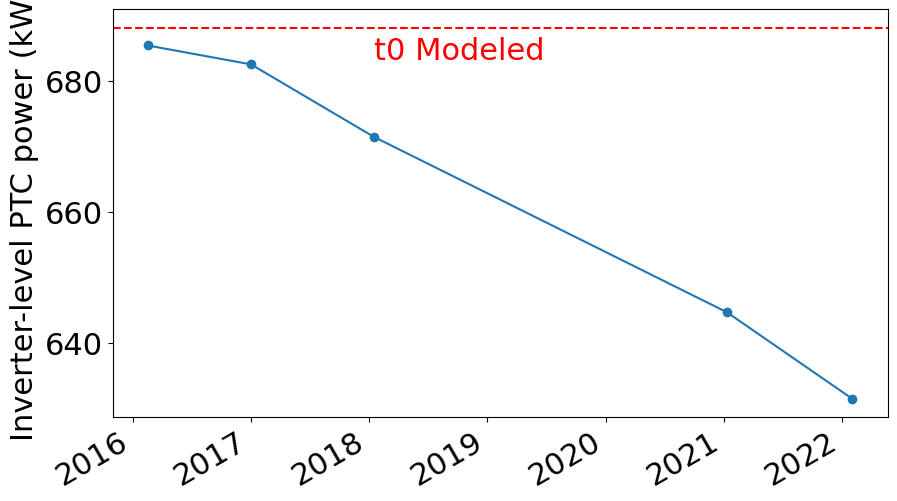

In [45]:

fig = plt.figure(figsize=(10,6))
plt.axhline(y=SAM_val, color='r', linestyle='--', label='SAM prediction')
plt.plot(power_predict_time, marker='o')
# add annotation for the SAM line
plt.text(power_predict_time.index[2], SAM_val-3.5, 't0 Modeled', color='r', va='center')
plt.ylabel('Inverter-level PTC power (kW)')
fig.autofmt_xdate()


In [ ]:
# calculate total degradation and degradation per year from power_predict_time
p_start = power_predict_time.iloc[0,0]
p_end = power_predict_time.iloc[-1,0]
print(f'Apparent degradation rate: {(p_end - p_start)/p_end/6*100:.2f}% per year median')
print(f'Apparent degradation: {(p_end - p_start)/p_end*100:.2f}% total')
print(f'Initial prediction: {p_start:.1f} kW, Final prediction: {p_end:.1f} kW')



Apparent degradation rate: -1.43% per year median
Apparent degradation: -8.56% total
Initial prediction: 687.8 kW, Final prediction: 633.6 kW


In [51]:
# to create a dithered scatterplot, use the array of values in 'random'  
# in order to get the x values for the scatterplot, use the 
# 



TypeError: Invalid type <class 'numpy.ndarray'>. Must be int or float.

In [56]:
start_dates[0] + pd.Timedelta(days=int(random[0]*7))

C:\Users\cdeline\AppData\Local\Temp\1\ipykernel_6092\3432513267.py:1: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  start_dates[0] + pd.Timedelta(days=int(random[0]*7))


Timestamp('2016-02-24 06:00:00-0500', tz='UTC-05:00')

In [57]:
i=0
scatter_dates = [start_dates[i] + pd.Timedelta(days=int(t*7)) for t in random[:-1]]

C:\Users\cdeline\AppData\Local\Temp\1\ipykernel_6092\1732733207.py:2: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  scatter_dates = [start_dates[i] + pd.Timedelta(days=int(t*7)) for t in random[:-1]]


In [60]:
start_dates[i]

Timestamp('2016-02-17 06:00:00-0500', tz='UTC-05:00')

In [67]:
df_temp.T

,power_predict
inverter_01_ac_power_(kw),625.378675
inverter_02_ac_power_(kw),609.703270
inverter_03_ac_power_(kw),627.229282
inverter_04_ac_power_(kw),627.503600
inverter_05_ac_power_(kw),628.856037
inverter_06_ac_power_(kw),644.844671
inverter_07_ac_power_(kw),640.537107
inverter_08_ac_power_(kw),616.965918
inverter_09_ac_power_(kw),624.181610
inverter_10_ac_power_(kw),623.401021


C:\Users\cdeline\AppData\Local\Temp\1\ipykernel_6092\2210077448.py:14: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  scatter_dates = [start_dates[i] + pd.Timedelta(days=int(t*10)) for t in random[:-1]]
C:\Users\cdeline\AppData\Local\Temp\1\ipykernel_6092\2210077448.py:14: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  scatter_dates = [start_dates[i] + pd.Timedelta(days=int(t*10)) for t in random[:-1]]
C:\Users\cdeline\AppData\Local\Temp\1\ipykernel_6092\2210077448.py:14: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before pe

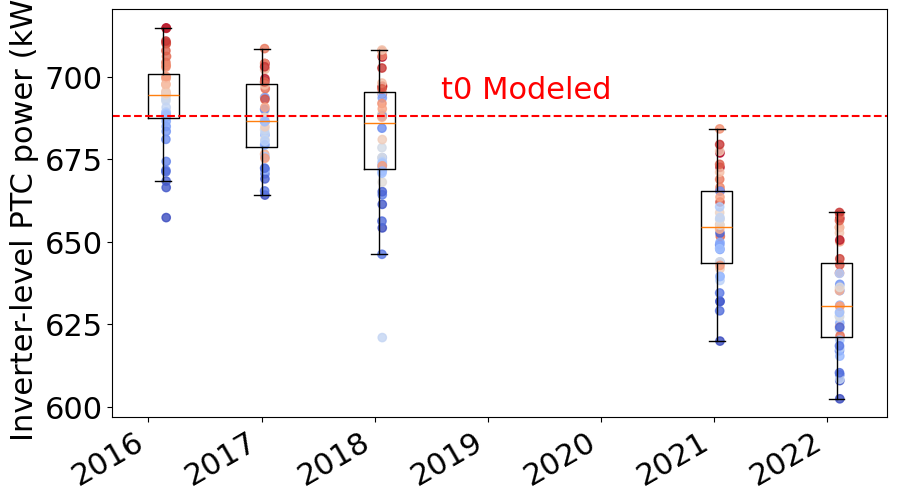

In [68]:
# re-load the annual captest results and overlay annual boxplots on the above time series plot.
import matplotlib.dates as mdates

fig = plt.figure(figsize=(10,6))
#plt.plot(power_predict_time, marker='o')

# Build a fixed color map from the first year so each inverter keeps the same color in all years.
df_ref = pd.read_csv(f'.\\data\\{start_dates[0].date().strftime("%Y-%m-%d")}_800poa20tmod.csv', index_col=0)
ref_vals = df_ref.T.iloc[:-1, 0].astype(float)
ref_rank = ref_vals.rank(method='first')
ref_rank_norm = ((ref_rank - 1) / (len(ref_rank) - 1)).to_dict()

for i in range(len(start_dates)):
    scatter_dates = [start_dates[i] + pd.Timedelta(days=int(t*10)) for t in random[:-1]]
    df_temp = pd.read_csv(f'.\\data\\{start_dates[i].date().strftime("%Y-%m-%d")}_800poa20tmod.csv', index_col=0)

    vals = df_temp.T.iloc[:-1, 0].astype(float)
    point_colors = vals.index.to_series().map(ref_rank_norm).to_numpy()
    plt.scatter(scatter_dates, vals.to_numpy(), c=point_colors, cmap='coolwarm', vmin=0, vmax=1, alpha=0.8)

    # Boxplot positions must be numeric for matplotlib; convert datetime to date number.
    xpos = mdates.date2num(start_dates[i].to_pydatetime())
    box_data = vals.dropna().values
    plt.boxplot([box_data], positions=[xpos], widths=100, showfliers=False, manage_ticks=False)

plt.axhline(y=SAM_val, color='r', linestyle='--', label='SAM prediction')
# add annotation for the SAM line
plt.text(power_predict_time.index[2]+pd.Timedelta(days=200), SAM_val+8, 't0 Modeled', color='r', va='center')
plt.ylabel('Inverter-level PTC power (kW)')
plt.gca().xaxis_date()
fig.autofmt_xdate()


